## Problem formulation

I am unemployed and expect to evaluate a finite number of job opportunities over a fixed time window.
Each opportunity can be scored using a rubric (salary, learning, stability, etc.).
I must decide when to stop searching and accept an employer.

### Hypothesis
A stopping strategy based on the exploration of ~37% of options, then accept the first option better than all seen so far, is optimal.

### What “better” means
I define a score function that maps employer attributes to a single number.


## Prime number 37: math foundations

37 is prime: it has exactly two positive divisors (1 and 37).
This section implements:
- primality testing
- sieve of Eratosthenes
- least prime factor (LPF) table for fast factorization


## Employer scoring model

Each employer has attributes normalized to [0, 1].
Score is a weighted sum:

Score = w_salary*Salary + w_learning*Learning + w_stability*Stability + w_remote*Remote + w_culture*Culture - w_commute*Commute

Weights reflect my priorities for every company/employer.


In [13]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


### Using real employers (recommended)
Replace the synthetic generator with a small table you fill manually:
- salary (normalized)
- learning potential
- stability
- remote/hybrid fit
- culture/team fit
- commute/time cost

Normalize each to [0,1], then compute fit_score with your weights.


In [14]:
# Define a function to generate a dataframe of employers with random attributes normalized to [0,1]
# This function is here to create synthetic data for simulating job opportunities
def generate_employers(N=30, seed=42):
    # Create a random number generator with a fixed seed for reproducible results
    # This ensures the same random data is generated each time for consistency in simulations
    rng = np.random.default_rng(seed)
    # Create a pandas DataFrame with columns for each employer attribute
    # Each attribute is filled with N random uniform values between 0 and 1
    # This simulates diverse employer characteristics
    df = pd.DataFrame({
        "salary": rng.uniform(0, 1, N),
        "learning": rng.uniform(0, 1, N),
        "stability": rng.uniform(0, 1, N),
        "remote": rng.uniform(0, 1, N),
        "culture": rng.uniform(0, 1, N),
        "commute": rng.uniform(0, 1, N),
    })
    # Return the generated dataframe
    return df

# Define a dictionary of weights for scoring employers
# These weights reflect personal priorities in the job search (e.g., salary is most important)
# The commute weight is noted to be subtracted, as higher commute is worse
weights = {
    "salary": 0.30,
    "learning": 0.25,
    "stability": 0.15,
    "remote": 0.15,
    "culture": 0.15,
    "commute": 0.20,  # subtract
}

# Define a function to calculate scores for employers based on attributes and weights
# This implements the scoring model described in the notebook's employer scoring section
def score_employers(df, w):
    # Compute the score as a weighted sum of attributes, subtracting the commute term
    # This formula combines all attributes into a single score for comparison
    score = (
        w["salary"]*df["salary"]
        + w["learning"]*df["learning"]
        + w["stability"]*df["stability"]
        + w["remote"]*df["remote"]
        + w["culture"]*df["culture"]
        - w["commute"]*df["commute"]
    )
    # Create a copy of the input dataframe to avoid modifying it directly
    out = df.copy()
    # Add the calculated score as a new column to the dataframe
    out["score"] = score
    # Return the dataframe with the added score column
    return out

# Generate a dataframe of 30 employers, score them using the defined weights, and assign to variable df
# This creates the main dataset for analysis and plotting in subsequent cells
df = score_employers(generate_employers(30), weights)

# Display the first 5 rows of the dataframe to verify the data and scores
# This is for quick inspection and debugging
df.head()

,salary,learning,stability,remote,culture,commute,score
0,0.773956,0.744762,0.668403,0.152312,0.584098,0.826292,0.463841
1,0.438878,0.967510,0.471096,0.696320,0.649847,0.896161,0.466898
2,0.858598,0.325825,0.565236,0.446156,0.084444,0.140249,0.475361
3,0.697368,0.370460,0.764999,0.381021,0.415807,0.554036,0.425292
4,0.094177,0.469556,0.634718,0.301512,0.041614,0.108576,0.270604


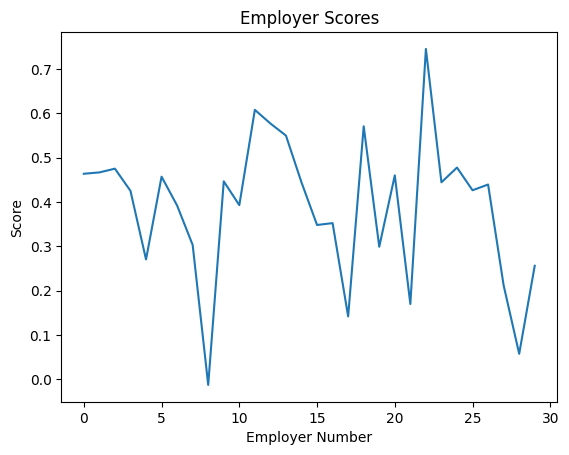

In [15]:
plt.plot(df.index, df['score'])
plt.xlabel('Employer Number')
plt.ylabel('Score')
plt.title('Employer Scores')
plt.show()

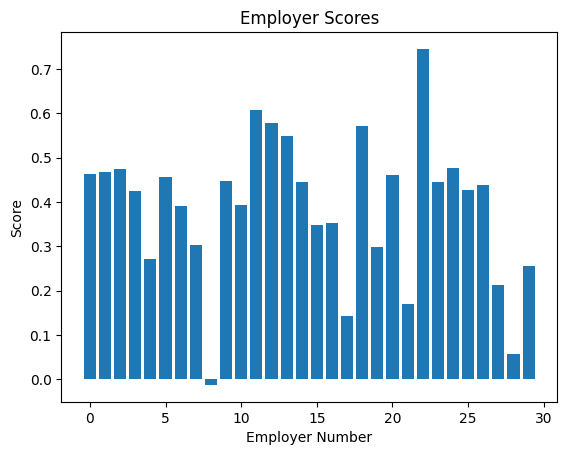

In [16]:
plt.bar(df.index, df['score'])
plt.xlabel('Employer Number')
plt.ylabel('Score')
plt.title('Employer Scores')
plt.show()

## The 37% rule

Let N be the number of employers I will evaluate.
Let S = floor(N / e) ≈ floor(0.37N).

1) Reject the first S employers, but remember the best score seen.
2) Accept the first later employer whose score exceeds that best-so-far.

We evaluate performance via simulation:
- probability of selecting the best employer
- average rank of selected employer
- regret (best_score - chosen_score)


In [17]:
def choose_employer(scores):
    # Calculate the total number of scores (employers) in the list
    N = len(scores)
    # Compute the rejection threshold r as the floor of N divided by e (approximately 37% of N)
    r = int(N / math.e)
    # Find the best score among the first r scores; if r is 0, set to negative infinity
    best_so_far = max(scores[:r]) if r > 0 else -float("inf")
    # Iterate through the remaining scores starting from index r
    for i in range(r, N):
        # If the current score is better than the best seen so far, return its index
        if scores[i] > best_so_far:
            return i
    # If no better score is found, return the index of the last employer
    return N - 1

def choose_first(scores):
    # Always choose the first employer (index 0)
    return 0

def choose_last(scores):
    # Always choose the last employer (index N-1)
    return len(scores) - 1

def choose_random(scores):
    # Choose a random employer index between 0 and N-1
    return random.randrange(len(scores))

In [18]:
def evaluate_once(N=30, seed=None):
    # Generate a dataframe of N employers with random attributes, score them using the predefined weights, and optionally use a provided seed for reproducibility
    df = score_employers(generate_employers(N, seed=seed if seed is not None else random.randint(0, 10**9)), weights)
    # Extract the scores as a numpy array for efficient numerical operations
    scores = df["score"].to_numpy()
    # Find the index of the best (maximum) score in the array
    best_idx = int(np.argmax(scores))
    # Get the best score value as a float
    best_score = float(scores[best_idx])
    
    # Define a dictionary mapping strategy names to their corresponding choice functions
    strategies = {
        "employer_37pct": choose_employer,
        "first": choose_first,
        "last": choose_last,
        "random": choose_random,
    }
    
    # Initialize an empty list to store results for each strategy
    results = []
    # Loop over each strategy name and its function
    for name, fn in strategies.items():
        # Apply the strategy function to the scores to get the chosen employer's index
        idx = fn(scores)
        # Get the score of the chosen employer as a float
        chosen_score = float(scores[idx])
        # Calculate the rank of the chosen score (1 being the best, higher numbers worse); count how many scores are better than chosen
        rank = int(np.sum(scores > chosen_score) + 1)  # 1 = best
        # Append a dictionary with results for this strategy to the results list
        results.append({
            "strategy": name,
            "chosen_idx": idx,
            "best_idx": best_idx,
            "picked_best": int(idx == best_idx),
            "rank": rank,
            "regret": best_score - chosen_score,
        })
    # Convert the list of result dictionaries to a pandas DataFrame and return it
    return pd.DataFrame(results)

# Call the function with N=30 and seed=1 to evaluate strategies once and display the results
evaluate_once(30, seed=1)

,strategy,chosen_idx,best_idx,picked_best,rank,regret
0,employer_37pct,12,26,0,4,0.065179
1,first,0,26,0,25,0.274985
2,last,29,26,0,6,0.107221
3,random,2,26,0,14,0.191999


## Practical version for real job searching

1) Decide a time window (e.g., 8 weeks) and estimate N serious opportunities.
2) For the first ~37% of that window, interview and learn—do not accept.
3) Build your “best so far” benchmark using your scoring rubric.
4) After that point, accept the first employer that beats your benchmark.

This is not a guarantee—it’s a rational strategy under clear assumptions.
